In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# Imports & load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


file_path = '/content/drive/MyDrive/MRP/news_preprocessed.csv'

news_df = pd.read_csv(file_path, parse_dates=['date'])
news_df = news_df.sort_values(['symbol', 'date']).reset_index(drop=True)

In [3]:
display(news_df.head())
news_df.info()

,date,symbol,avg_sentiment,avg_sentiment_score,news_count
0,2016-01-06,A,0.0,0.999295,2
1,2016-01-07,A,0.5,0.992147,2
2,2016-02-05,A,0.0,0.997771,1
3,2016-02-10,A,0.0,0.999134,1
4,2016-02-15,A,0.0,0.999934,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848357 entries, 0 to 1848356
Data columns (total 5 columns):
 #   Column               Dtype         
---  ------               -----         
 0   date                 datetime64[ns]
 1   symbol               object        
 2   avg_sentiment        float64       
 3   avg_sentiment_score  float64       
 4   news_count           int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 70.5+ MB


In [4]:
# Missingness & Summary Stats
print("\nMissing values per column:")
print(news_df.isnull().sum())
print("\nDescriptive statistics:")
display(news_df.describe())



Missing values per column:
date                   0
symbol                 0
avg_sentiment          0
avg_sentiment_score    0
news_count             0
dtype: int64

Descriptive statistics:


,date,avg_sentiment,avg_sentiment_score,news_count
count,1848357,1.848357e+06,1.848357e+06,1.848357e+06
mean,2019-06-23 14:46:18.184083968,1.733623e-01,9.635151e-01,2.178298e+00
min,2016-01-01 00:00:00,-1.000000e+00,3.354929e-01,1.000000e+00
25%,2017-10-05 00:00:00,0.000000e+00,9.780515e-01,1.000000e+00
50%,2019-03-06 00:00:00,0.000000e+00,9.995175e-01,1.000000e+00
75%,2021-01-13 00:00:00,5.000000e-01,9.999791e-01,2.000000e+00
max,2023-12-31 00:00:00,1.000000e+00,1.000000e+00,1.546000e+03
std,NaN,5.533365e-01,8.555550e-02,1.216135e+01


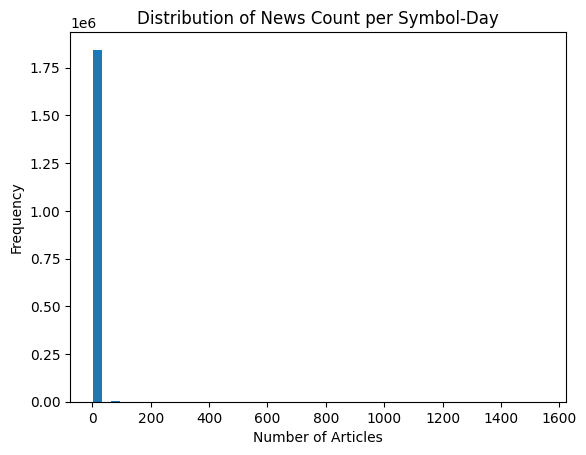

In [5]:
# Distribution of Article Counts per Day
plt.figure()
plt.hist(news_df['news_count'], bins=50)
plt.title('Distribution of News Count per Symbol-Day')
plt.xlabel('Number of Articles')
plt.ylabel('Frequency')
plt.show()

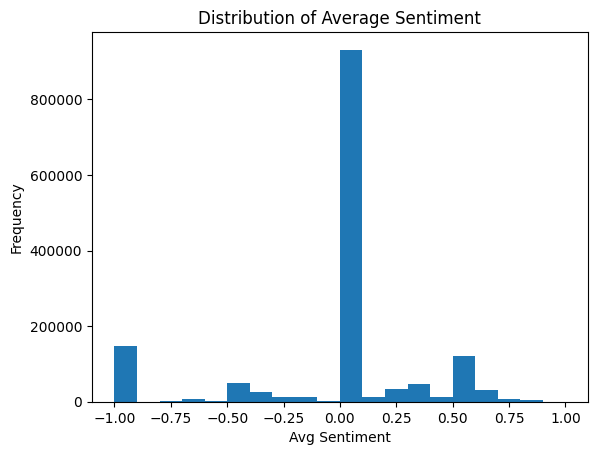

In [6]:
# Sentiment Label Distribution
plt.figure()
# avg_sentiment ranges from -1 to +1
plt.hist(news_df['avg_sentiment'], bins=np.arange(-1,1.1,0.1))
plt.title('Distribution of Average Sentiment')
plt.xlabel('Avg Sentiment')
plt.ylabel('Frequency')
plt.show()

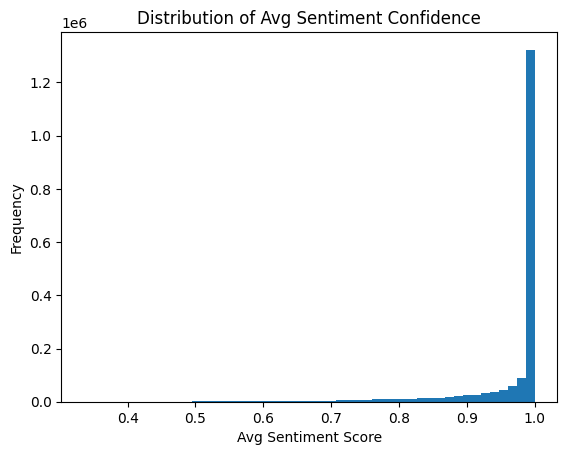

In [7]:
# Sentiment Confidence Score Distribution
plt.figure()
plt.hist(news_df['avg_sentiment_score'], bins=50)
plt.title('Distribution of Avg Sentiment Confidence')
plt.xlabel('Avg Sentiment Score')
plt.ylabel('Frequency')
plt.show()

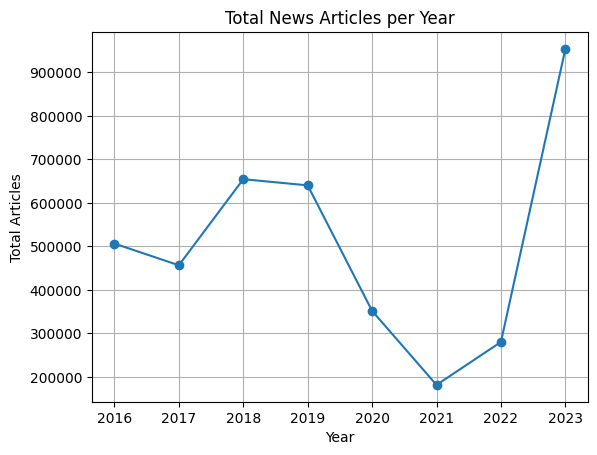

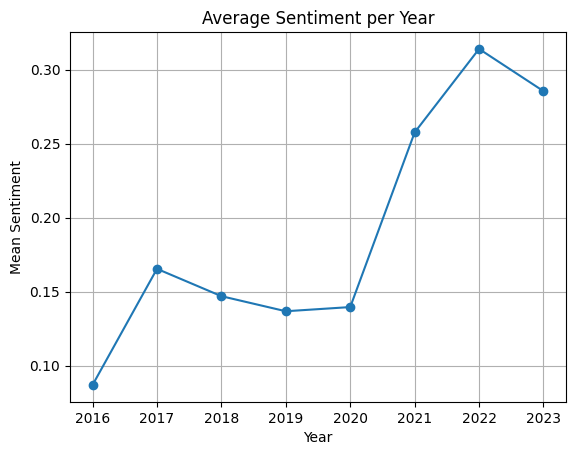

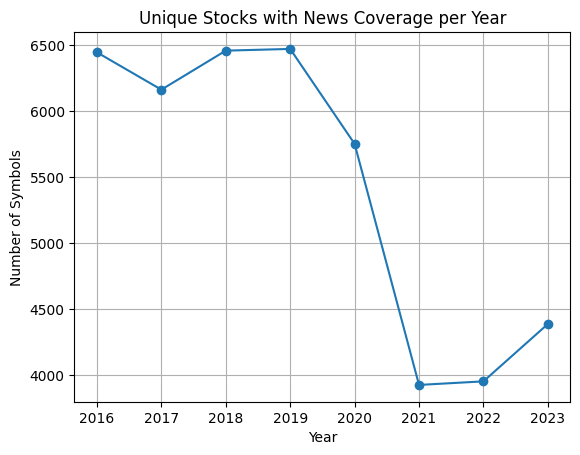

In [9]:
# Temporal Trends by Year
news_df['year'] = news_df['date'].dt.year
# Total articles per year
annual_articles = news_df.groupby('year')['news_count'].sum()
plt.figure()
plt.plot(annual_articles.index, annual_articles.values, marker='o')
plt.title('Total News Articles per Year')
plt.xlabel('Year')
plt.ylabel('Total Articles')
plt.grid(True)
plt.show()

# Average sentiment per year
annual_sent = news_df.groupby('year')['avg_sentiment'].mean()
plt.figure()
plt.plot(annual_sent.index, annual_sent.values, marker='o')
plt.title('Average Sentiment per Year')
plt.xlabel('Year')
plt.ylabel('Mean Sentiment')
plt.grid(True)
plt.show()

# Unique symbols covered per year
symbols_per_year = news_df.groupby('year')['symbol'].nunique()
plt.figure()
plt.plot(symbols_per_year.index, symbols_per_year.values, marker='o')
plt.title('Unique Stocks with News Coverage per Year')
plt.xlabel('Year')
plt.ylabel('Number of Symbols')
plt.grid(True)
plt.show()


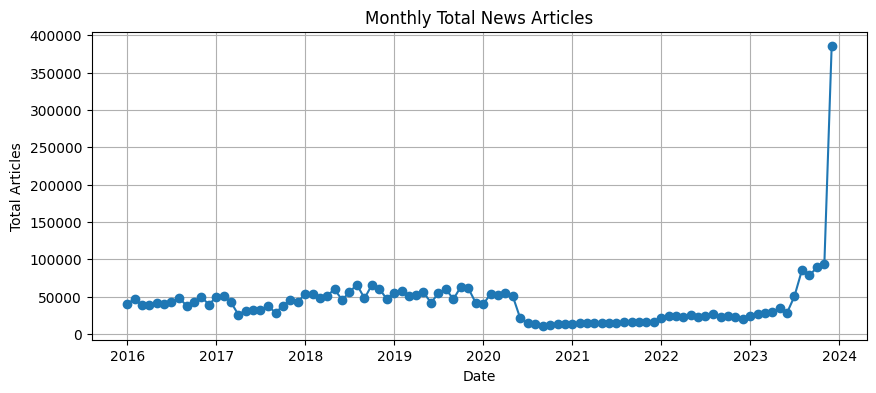

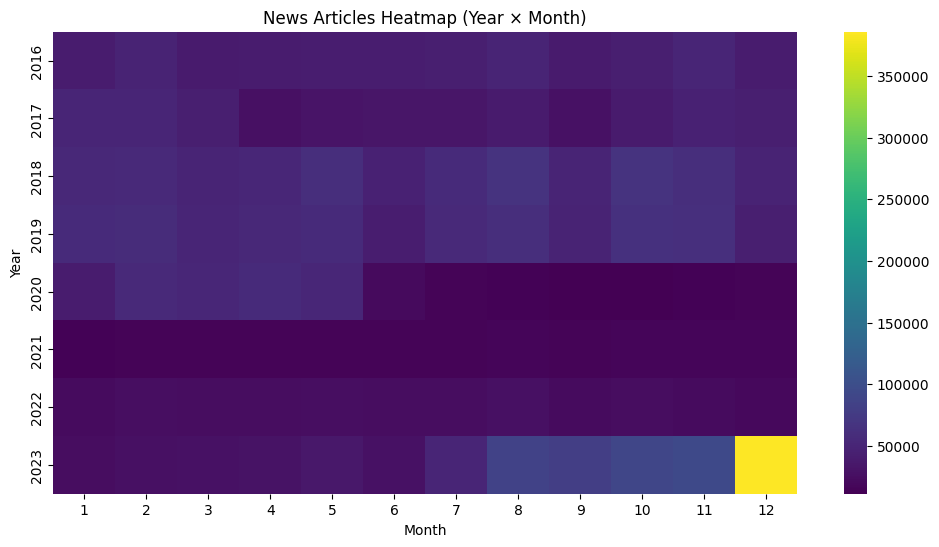

In [11]:
# Monthly Article Trends

# Line chart of total monthly articles
news_df['year_month'] = news_df['date'].dt.to_period('M')
monthly = news_df.groupby('year_month')['news_count'].sum()

plt.figure(figsize=(10,4))
monthly.index = monthly.index.to_timestamp()
plt.plot(monthly.index, monthly.values, marker='o', linestyle='-')
plt.title('Monthly Total News Articles')
plt.xlabel('Date')
plt.ylabel('Total Articles')
plt.grid(True)
plt.show()


# Heatmap of articles by Year vs. Month
import seaborn as sns

# extract year and month
news_df['year'] = news_df['date'].dt.year
news_df['month'] = news_df['date'].dt.month

# pivot table
pivot = news_df.pivot_table(
    index='year',
    columns='month',
    values='news_count',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='viridis', annot=False, fmt='g')
plt.title('News Articles Heatmap (Year × Month)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

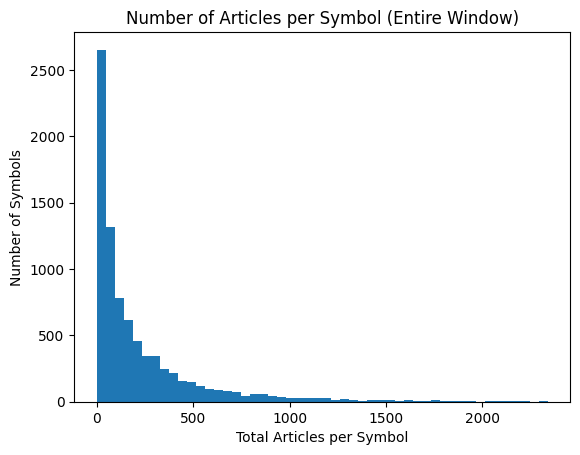

Top 10 Symbols by Article Count:


,count
symbol,
T,2339
BABA,2295
KO,2240
WFC,2237
SBUX,2210
GILD,2206
MRK,2182
CMCSA,2173
GE,2147


In [12]:

# Symbol-Level Coverage
symbol_counts = news_df['symbol'].value_counts()
plt.figure()
plt.hist(symbol_counts, bins=50)
plt.title('Number of Articles per Symbol (Entire Window)')
plt.xlabel('Total Articles per Symbol')
plt.ylabel('Number of Symbols')
plt.show()

print("Top 10 Symbols by Article Count:")
display(symbol_counts.head(10))


Correlation matrix:
                      avg_sentiment  avg_sentiment_score  news_count
avg_sentiment             1.000000             0.036737    0.006895
avg_sentiment_score       0.036737             1.000000   -0.004925
news_count                0.006895            -0.004925    1.000000


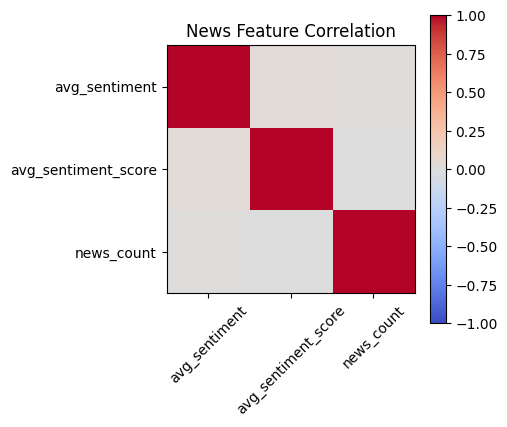

In [13]:
# Correlation Matrix & Scatter
corr = news_df[['avg_sentiment','avg_sentiment_score','news_count']].corr()
print("Correlation matrix:\n", corr)

plt.figure(figsize=(4,4))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title('News Feature Correlation')
plt.show()


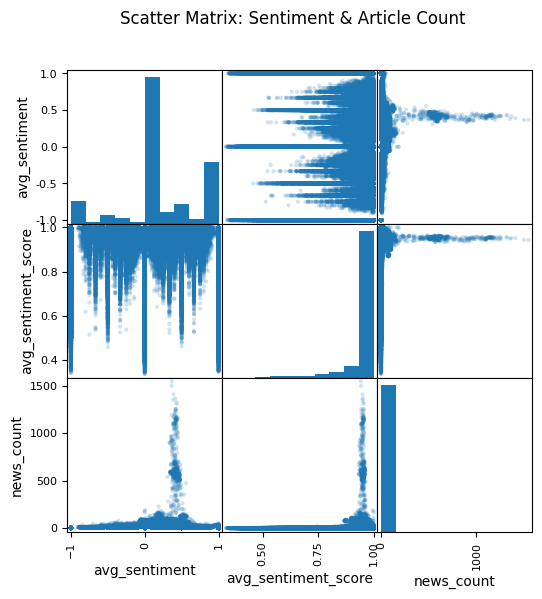

In [14]:
# Scatter matrix
filtered = news_df[['avg_sentiment','avg_sentiment_score','news_count']].dropna()
scatter_matrix(filtered, alpha=0.2, figsize=(6,6), diagonal='hist')
plt.suptitle('Scatter Matrix: Sentiment & Article Count')
plt.show()